# Machine Learning Models

**Logistic Regression**

Optimization terminated successfully.
         Current function value: 0.410801
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            Default_12M   No. Observations:                 2400
Model:                          Logit   Df Residuals:                     2392
Method:                           MLE   Df Model:                            7
Date:                Fri, 27 Mar 2026   Pseudo R-squ.:                  0.1422
Time:                        17:33:49   Log-Likelihood:                -985.92
converged:                       True   LL-Null:                       -1149.3
Covariance Type:            nonrobust   LLR p-value:                 1.116e-66
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.7408      0.064    -27.264      0.000      -1.866      -1.616
Cu

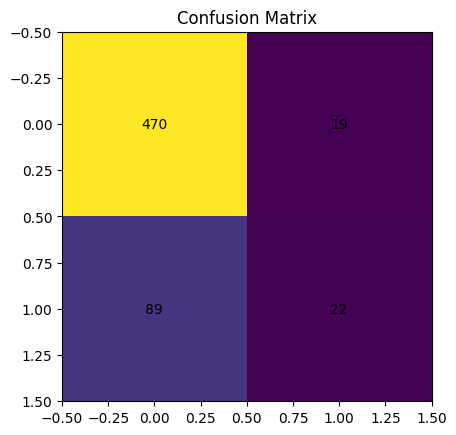

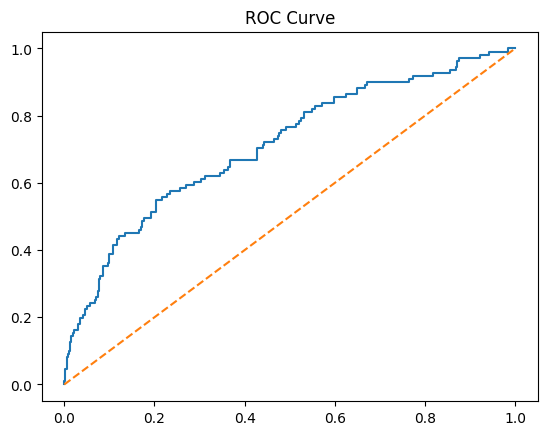

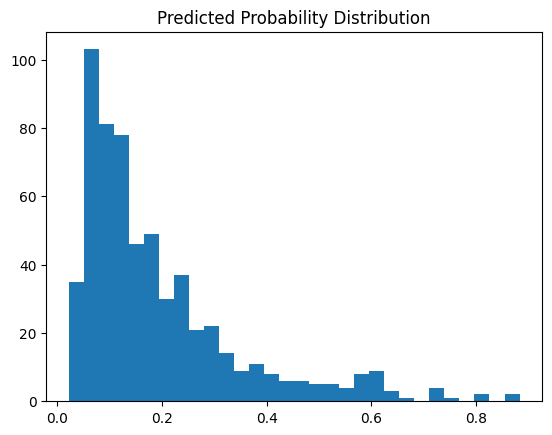

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import statsmodels.api as sm

df = pd.read_excel('/content/credit_default.xlsx')

target_column = 'Default_12M'

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Reset indices to ensure alignment after splitting and for statsmodels
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

X_train_sm = sm.add_constant(X_train_scaled)

model_full = sm.Logit(y_train, X_train_sm).fit()

print(model_full.summary())

p_values = model_full.pvalues
selected_features = p_values[p_values < 0.05].index.tolist()

if 'const' in selected_features:
    selected_features.remove('const')

X_train_selected = X_train_scaled[selected_features]
X_test_selected = X_test_scaled[selected_features]

X_train_selected_sm = sm.add_constant(X_train_selected)
X_test_selected_sm = sm.add_constant(X_test_selected)

model_final = sm.Logit(y_train, X_train_selected_sm).fit()

print(model_final.summary())

coefficients = model_final.params

coef_df = pd.DataFrame({
    'Feature': coefficients.index,
    'Coefficient': coefficients.values
})

print(coef_df)

intercept = coefficients['const']
equation = f"logit(p) = {intercept:.4f}"

for feature in selected_features:
    coef = coefficients[feature]
    equation += f" + ({coef:.4f} * {feature})"

print("\nLogistic Regression Equation:")
print(equation)

y_prob = model_final.predict(X_test_selected_sm)
y_pred = (y_prob >= 0.5).astype(int)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
print("\nClassification Report:\n", report)

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

plt.figure()
plt.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()

plt.figure()
plt.hist(y_prob, bins=30)
plt.title("Predicted Probability Distribution")
plt.show()



**KNN**

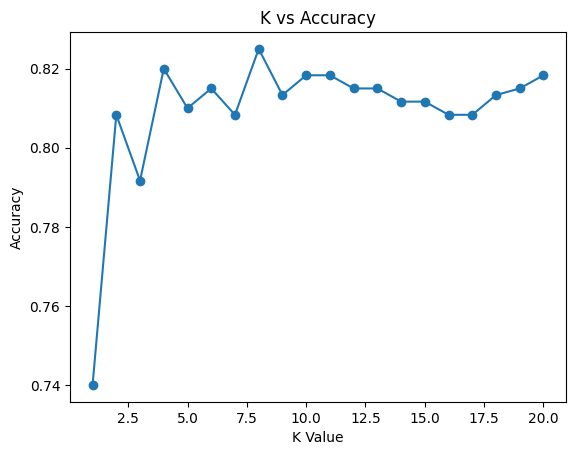

Optimal K: 8
Accuracy: 0.825

Confusion Matrix:
 [[475  14]
 [ 91  20]]

Classification Report:
               precision    recall  f1-score  support
0              0.839223  0.971370  0.900474  489.000
1              0.588235  0.180180  0.275862  111.000
accuracy       0.825000  0.825000  0.825000    0.825
macro avg      0.713729  0.575775  0.588168  600.000
weighted avg   0.792790  0.825000  0.784921  600.000

ROC-AUC Score: 0.639022458040863


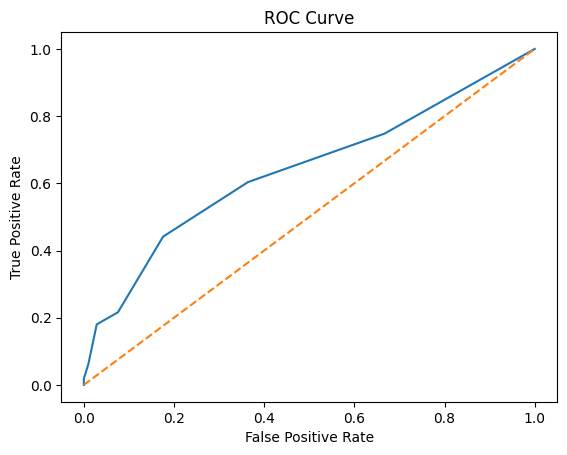

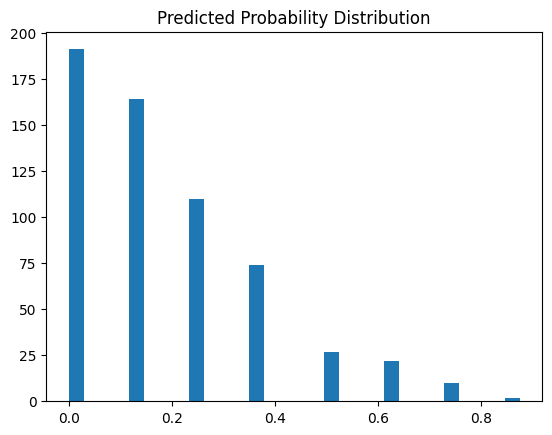

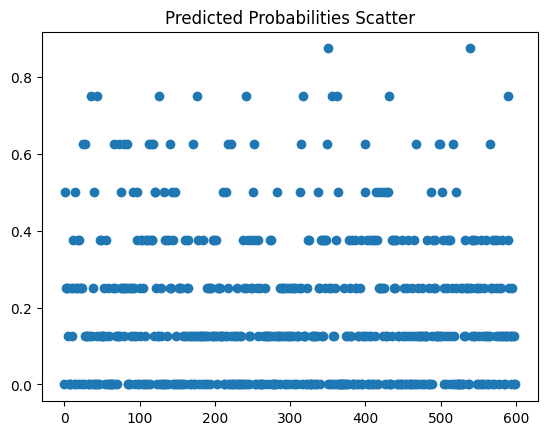

In [33]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

df = pd.read_excel('/content/credit_default.xlsx')

target_column = 'Default_12M'

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred_k = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_k))

optimal_k = k_values[np.argmax(accuracies)]

plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

model = KNeighborsClassifier(n_neighbors=optimal_k)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print("Optimal K:", optimal_k)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("\nClassification Report:\n", report_df)

roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

plt.figure()
plt.hist(y_prob, bins=30)
plt.title("Predicted Probability Distribution")
plt.show()

plt.figure()
plt.scatter(range(len(y_prob)), y_prob)
plt.title("Predicted Probabilities Scatter")
plt.show()



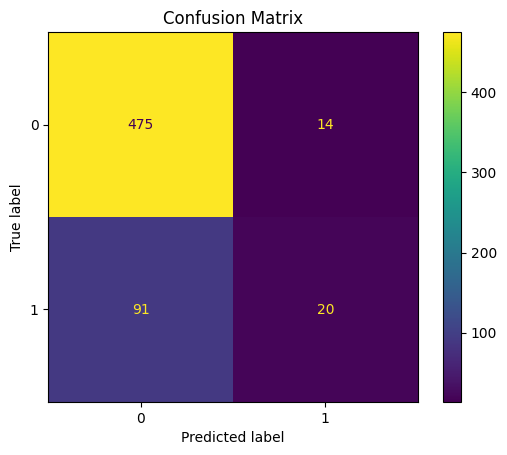

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

**Naive Byes**

Accuracy: 0.7883333333333333

Confusion Matrix:
 [[441  48]
 [ 79  32]]

Classification Report:
               precision    recall  f1-score     support
0              0.848077  0.901840  0.874133  489.000000
1              0.400000  0.288288  0.335079  111.000000
accuracy       0.788333  0.788333  0.788333    0.788333
macro avg      0.624038  0.595064  0.604606  600.000000
weighted avg   0.765183  0.788333  0.774408  600.000000

ROC-AUC Score: 0.6965493100462425


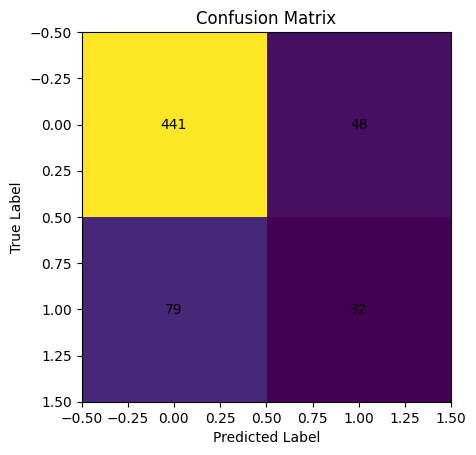

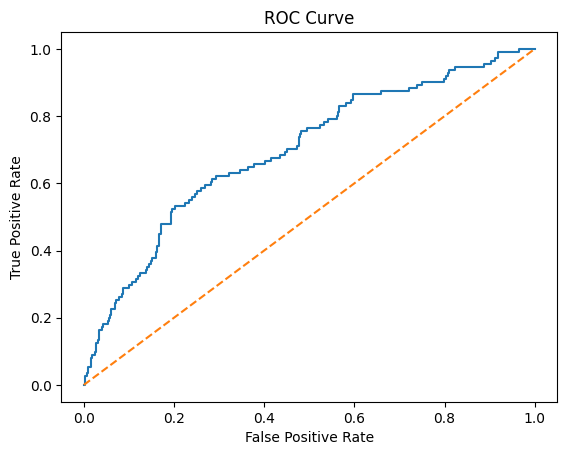

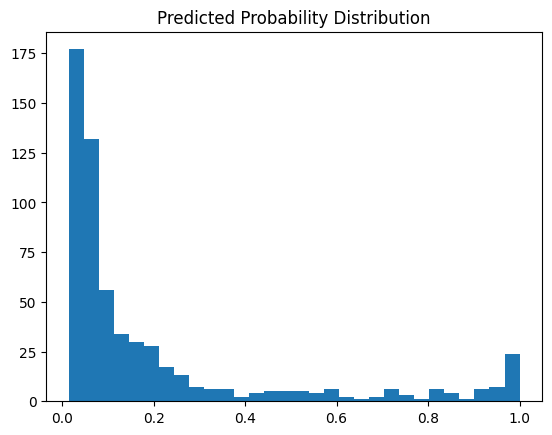

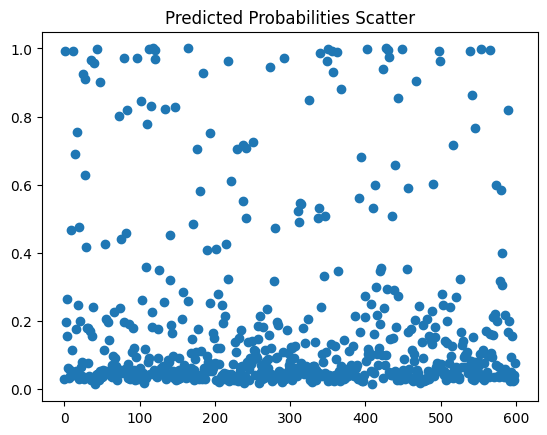

In [34]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

df = pd.read_excel('/content/credit_default.xlsx')

target_column = 'Default_12M'

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = GaussianNB()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("\nClassification Report:\n", report_df)

roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC-AUC Score:", roc_auc)

plt.figure()
plt.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

plt.figure()
plt.hist(y_prob, bins=30)
plt.title("Predicted Probability Distribution")
plt.show()

plt.figure()
plt.scatter(range(len(y_prob)), y_prob)
plt.title("Predicted Probabilities Scatter")
plt.show()



**Decision Tree**

Optimal Depth (CV): 2


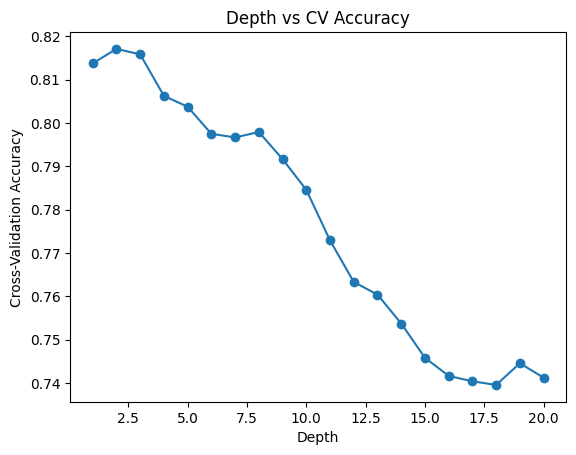

Test Accuracy: 0.8066666666666666

Confusion Matrix:
 [[468  21]
 [ 95  16]]

Classification Report:
               precision    recall  f1-score     support
0              0.831261  0.957055  0.889734  489.000000
1              0.432432  0.144144  0.216216  111.000000
accuracy       0.806667  0.806667  0.806667    0.806667
macro avg      0.631847  0.550600  0.552975  600.000000
weighted avg   0.757478  0.806667  0.765133  600.000000

ROC-AUC Score: 0.6461799222535418


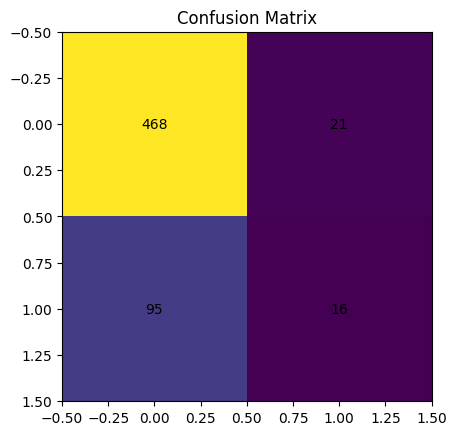

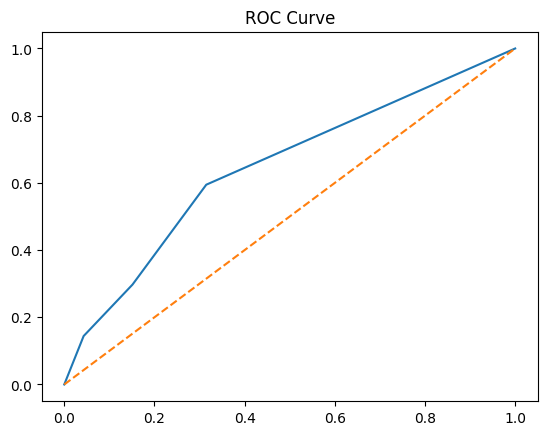


Feature Importance:
                Feature  Importance
6   Past_Delinquencies    0.529234
3  EMI_to_Income_Ratio    0.470766
0          Customer_ID    0.000000
2      EMI_Monthly_INR    0.000000
1   Income_Monthly_INR    0.000000
4         Credit_Score    0.000000
5        Tenure_Months    0.000000


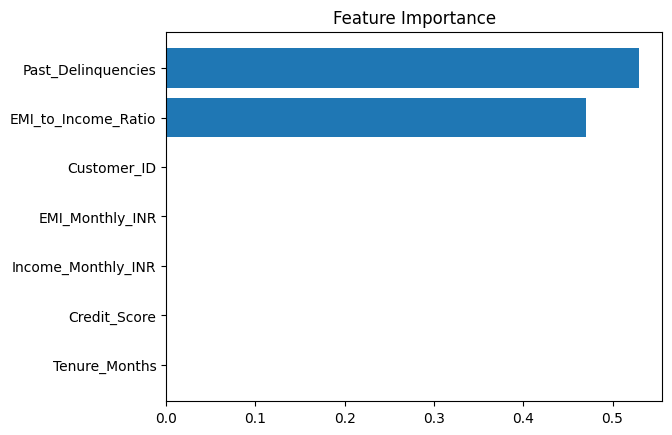

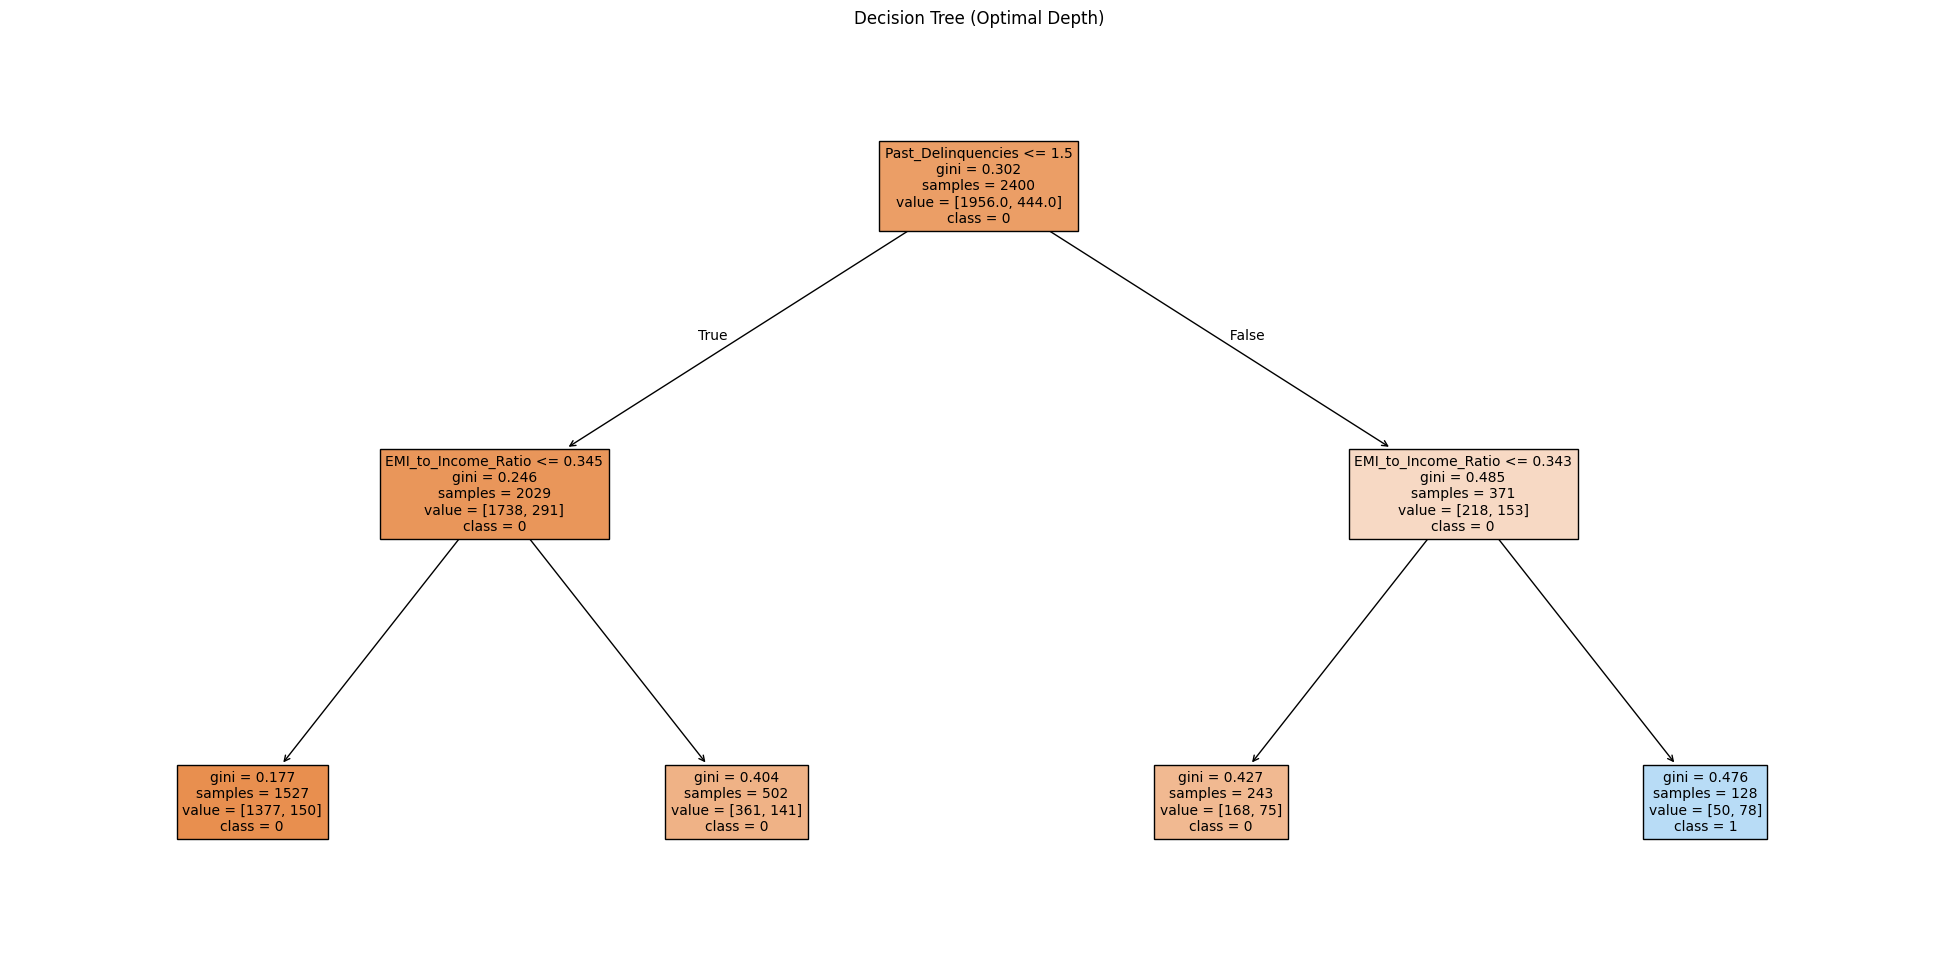

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

df = pd.read_excel('/content/credit_default.xlsx')

target_column = 'Default_12M'

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

depths = range(1, 21)
cv_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_depth = depths[np.argmax(cv_scores)]

print("Optimal Depth (CV):", optimal_depth)

plt.figure()
plt.plot(depths, cv_scores, marker='o')
plt.xlabel("Depth")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Depth vs CV Accuracy")
plt.show()

model = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
print("\nClassification Report:\n", report)

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

plt.figure()
plt.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", importance)

plt.figure()
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

plt.figure(figsize=(25,12))
plot_tree(model, feature_names=X.columns, class_names=['0','1'], filled=True, fontsize=10)
plt.title("Decision Tree (Optimal Depth)")
plt.show()



**Random Forest**

Optimal n_estimators: 50


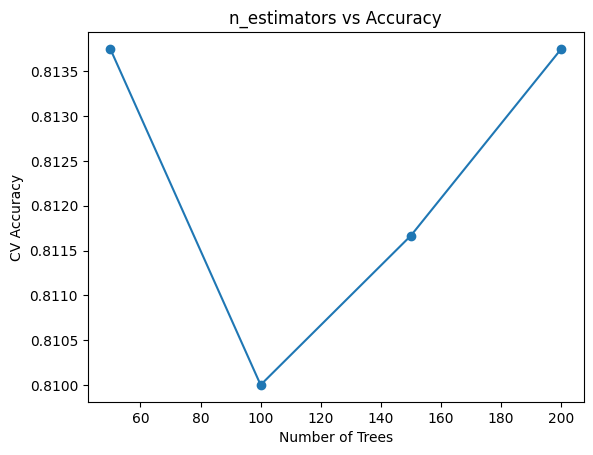

Test Accuracy: 0.8166666666666667

Confusion Matrix:
 [[469  20]
 [ 90  21]]

Classification Report:
               precision    recall  f1-score     support
0              0.838998  0.959100  0.895038  489.000000
1              0.512195  0.189189  0.276316  111.000000
accuracy       0.816667  0.816667  0.816667    0.816667
macro avg      0.675597  0.574145  0.585677  600.000000
weighted avg   0.778540  0.816667  0.780575  600.000000

ROC-AUC Score: 0.6474879787763224


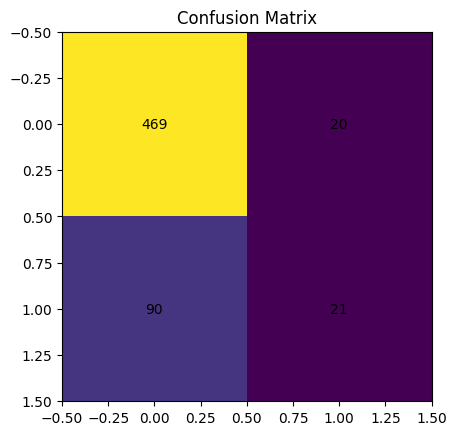

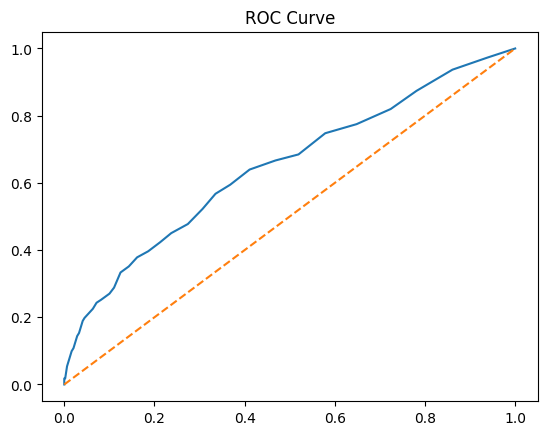


Feature Importance:
                Feature  Importance
3  EMI_to_Income_Ratio    0.195342
2      EMI_Monthly_INR    0.173573
1   Income_Monthly_INR    0.156398
4         Credit_Score    0.156102
0          Customer_ID    0.148810
6   Past_Delinquencies    0.097037
5        Tenure_Months    0.072738


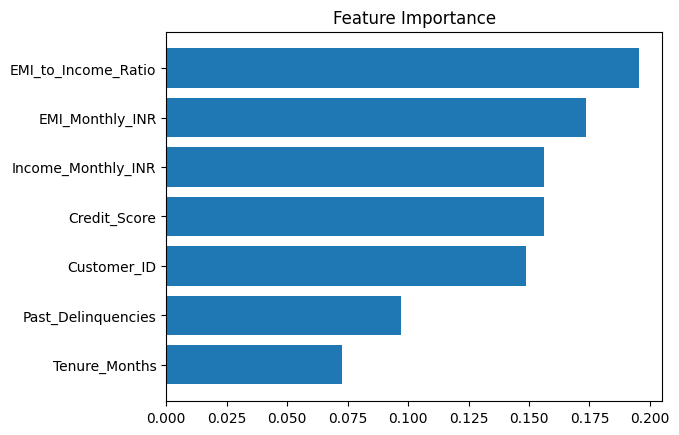

In [36]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

df = pd.read_excel('/content/credit_default.xlsx')

target_column = 'Default_12M'

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

n_values = [50, 100, 150, 200]
cv_scores = []

for n in n_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_n = n_values[np.argmax(cv_scores)]

print("Optimal n_estimators:", optimal_n)

plt.figure()
plt.plot(n_values, cv_scores, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("CV Accuracy")
plt.title("n_estimators vs Accuracy")
plt.show()

model = RandomForestClassifier(n_estimators=optimal_n, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
print("\nClassification Report:\n", report)

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

plt.figure()
plt.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", importance)

plt.figure()
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()



**Adaboost**

Optimal n_estimators: 50


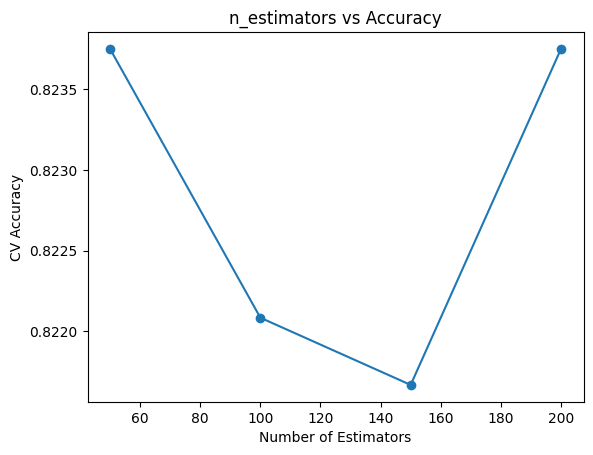

Test Accuracy: 0.8116666666666666

Confusion Matrix:
 [[469  20]
 [ 93  18]]

Classification Report:
               precision    recall  f1-score     support
0              0.834520  0.959100  0.892483  489.000000
1              0.473684  0.162162  0.241611  111.000000
accuracy       0.811667  0.811667  0.811667    0.811667
macro avg      0.654102  0.560631  0.567047  600.000000
weighted avg   0.767765  0.811667  0.772072  600.000000

ROC-AUC Score: 0.6957294718030915


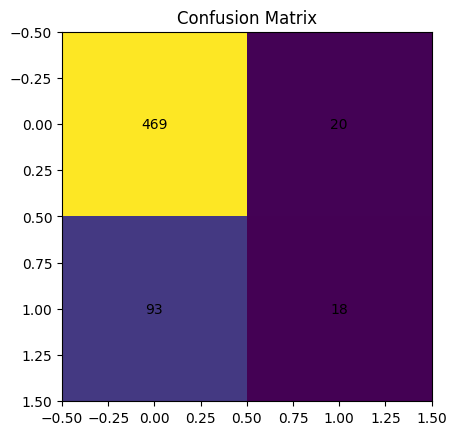

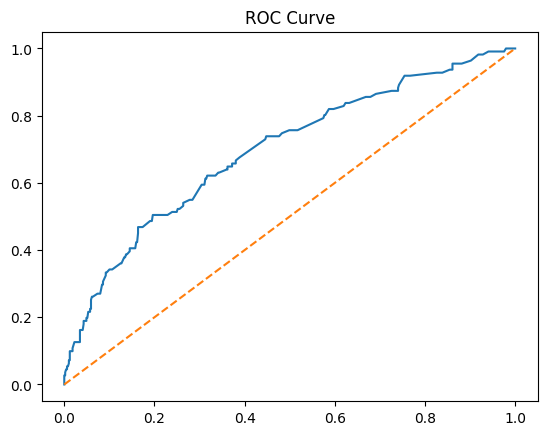


Feature Importance:
                Feature  Importance
6   Past_Delinquencies    0.476254
3  EMI_to_Income_Ratio    0.170829
0          Customer_ID    0.124743
4         Credit_Score    0.117546
5        Tenure_Months    0.055730
1   Income_Monthly_INR    0.054898
2      EMI_Monthly_INR    0.000000


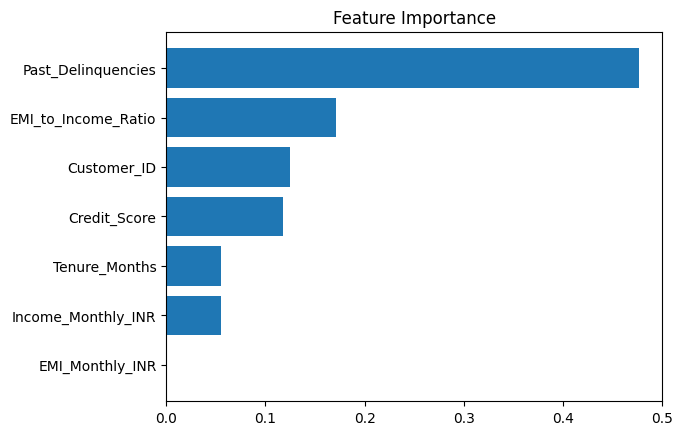

In [37]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

df = pd.read_excel('/content/credit_default.xlsx')

target_column = 'Default_12M'

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

n_values = [50, 100, 150, 200]
cv_scores = []

for n in n_values:
    model = AdaBoostClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_n = n_values[np.argmax(cv_scores)]

print("Optimal n_estimators:", optimal_n)

plt.figure()
plt.plot(n_values, cv_scores, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("CV Accuracy")
plt.title("n_estimators vs Accuracy")
plt.show()

model = AdaBoostClassifier(n_estimators=optimal_n, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
print("\nClassification Report:\n", report)

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

plt.figure()
plt.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", importance)

plt.figure()
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()



**Gradient Boost**

Optimal n_estimators: 50


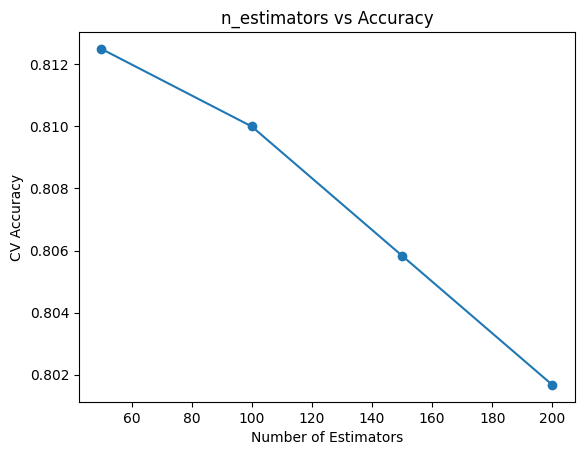

Test Accuracy: 0.81

Confusion Matrix:
 [[467  22]
 [ 92  19]]

Classification Report:
               precision    recall  f1-score  support
0              0.835420  0.955010  0.891221   489.00
1              0.463415  0.171171  0.250000   111.00
accuracy       0.810000  0.810000  0.810000     0.81
macro avg      0.649418  0.563091  0.570611   600.00
weighted avg   0.766599  0.810000  0.772595   600.00

ROC-AUC Score: 0.6958215884596252


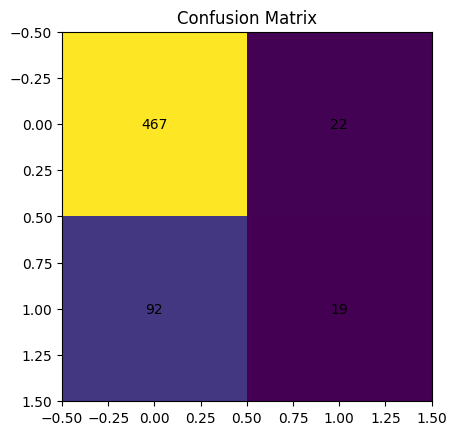

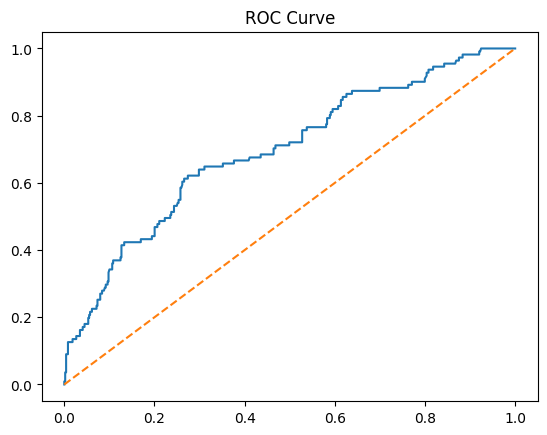


Feature Importance:
                Feature  Importance
3  EMI_to_Income_Ratio    0.315025
6   Past_Delinquencies    0.304430
1   Income_Monthly_INR    0.120594
4         Credit_Score    0.096787
0          Customer_ID    0.082244
2      EMI_Monthly_INR    0.045665
5        Tenure_Months    0.035254


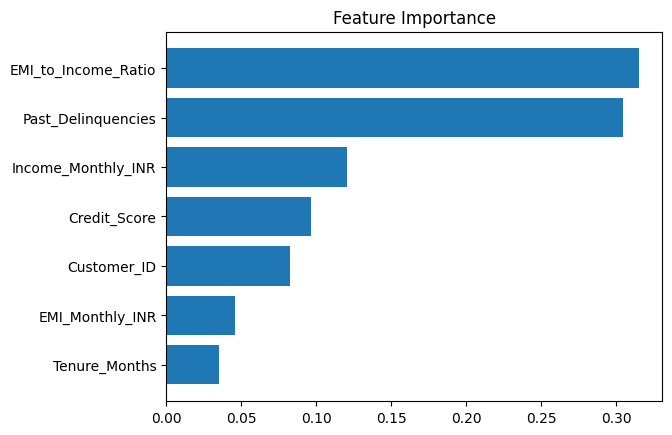

In [38]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

df = pd.read_excel('/content/credit_default.xlsx')

target_column = 'Default_12M'

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

n_values = [50, 100, 150, 200]
cv_scores = []

for n in n_values:
    model = GradientBoostingClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_n = n_values[np.argmax(cv_scores)]

print("Optimal n_estimators:", optimal_n)

plt.figure()
plt.plot(n_values, cv_scores, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("CV Accuracy")
plt.title("n_estimators vs Accuracy")
plt.show()

model = GradientBoostingClassifier(n_estimators=optimal_n, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
print("\nClassification Report:\n", report)

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

plt.figure()
plt.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", importance)

plt.figure()
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()



**XG Boost**

Optimal n_estimators: 50


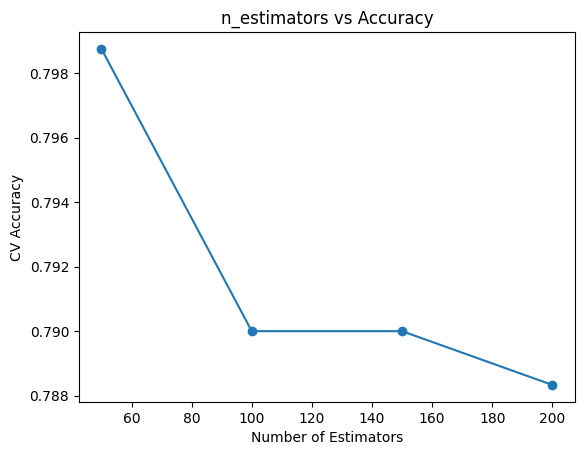

Test Accuracy: 0.785

Confusion Matrix:
 [[450  39]
 [ 90  21]]

Classification Report:
               precision    recall  f1-score  support
0              0.833333  0.920245  0.874636  489.000
1              0.350000  0.189189  0.245614  111.000
accuracy       0.785000  0.785000  0.785000    0.785
macro avg      0.591667  0.554717  0.560125  600.000
weighted avg   0.743917  0.785000  0.758267  600.000

ROC-AUC Score: 0.6469352788371194


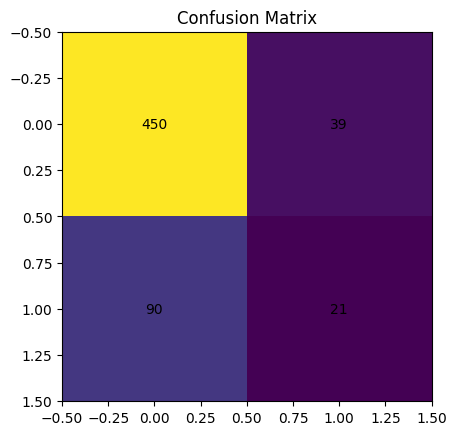

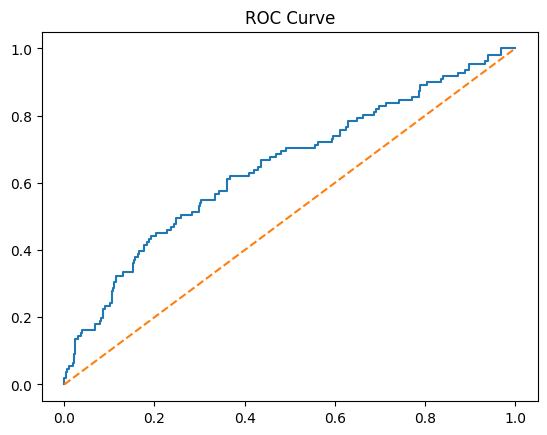


Feature Importance:
                Feature  Importance
6   Past_Delinquencies    0.334364
3  EMI_to_Income_Ratio    0.165249
2      EMI_Monthly_INR    0.109891
5        Tenure_Months    0.105214
1   Income_Monthly_INR    0.100614
4         Credit_Score    0.094302
0          Customer_ID    0.090365


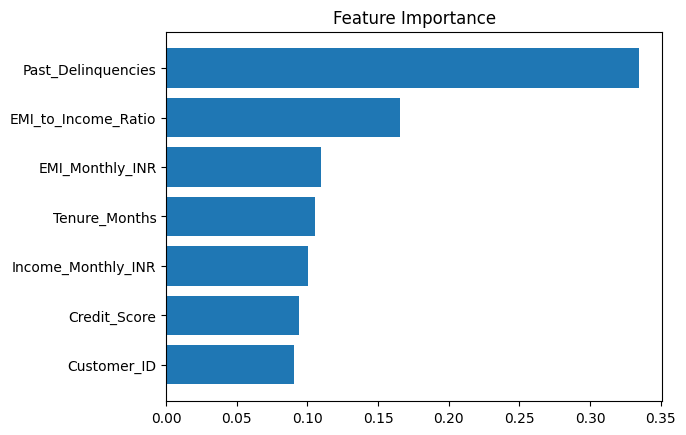

In [39]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import xgboost as xgb

df = pd.read_excel('/content/credit_default.xlsx')

target_column = 'Default_12M'

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

n_values = [50, 100, 150, 200]
cv_scores = []

for n in n_values:
    model = xgb.XGBClassifier(n_estimators=n, eval_metric='logloss', random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_n = n_values[np.argmax(cv_scores)]

print("Optimal n_estimators:", optimal_n)

plt.figure()
plt.plot(n_values, cv_scores, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("CV Accuracy")
plt.title("n_estimators vs Accuracy")
plt.show()

model = xgb.XGBClassifier(n_estimators=optimal_n, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
print("\nClassification Report:\n", report)

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

plt.figure()
plt.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", importance)

plt.figure()
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()



**LightGBM**

[LightGBM] [Info] Number of positive: 356, number of negative: 1564
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000319 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1291
[LightGBM] [Info] Number of data points in the train set: 1920, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.185417 -> initscore=-1.480071
[LightGBM] [Info] Start training from score -1.480071
[LightGBM] [Info] Number of positive: 355, number of negative: 1565
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 1920, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.184896 -> initscore=-1.483523
[LightGBM] [Info] Start training from score -1.483523
[LightGBM] [Info] Numb

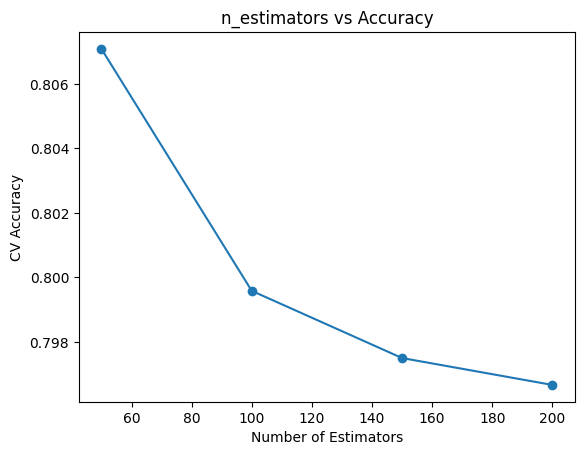

[LightGBM] [Info] Number of positive: 444, number of negative: 1956
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000199 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.185000 -> initscore=-1.482832
[LightGBM] [Info] Start training from score -1.482832
Test Accuracy: 0.8066666666666666

Confusion Matrix:
 [[464  25]
 [ 91  20]]

Classification Report:
               precision    recall  f1-score     support
0              0.836036  0.948875  0.888889  489.000000
1              0.444444  0.180180  0.256410  111.000000
accuracy       0.806667  0.806667  0.806667    0.806667
macro avg      0.640240  0.564528  0.572650  600.000000
weighted avg   0.763592  0.806667  0.771880  600.000000

ROC-AUC 

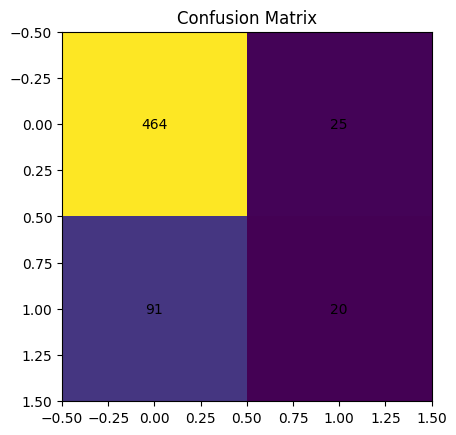

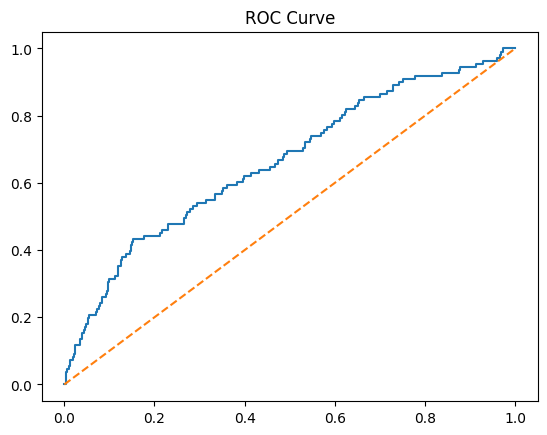


Feature Importance:
                Feature  Importance
3  EMI_to_Income_Ratio         277
1   Income_Monthly_INR         275
0          Customer_ID         273
4         Credit_Score         256
2      EMI_Monthly_INR         236
5        Tenure_Months          97
6   Past_Delinquencies          86


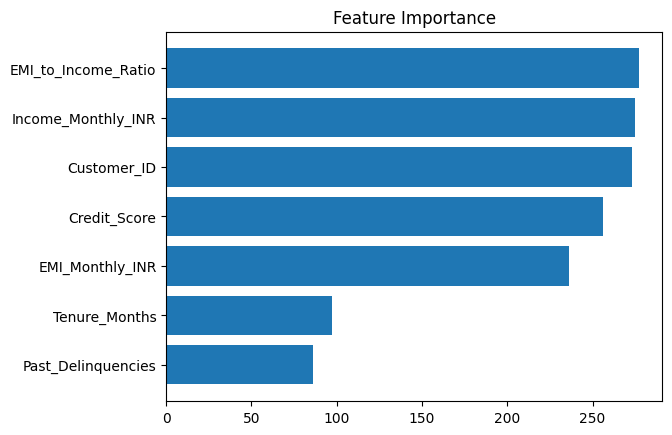

In [32]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import lightgbm as lgb

df = pd.read_excel('/content/credit_default.xlsx')

target_column = 'Default_12M' # Corrected column name

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

n_values = [50, 100, 150, 200]
cv_scores = []

for n in n_values:
    model = lgb.LGBMClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_n = n_values[np.argmax(cv_scores)]

print("Optimal n_estimators:", optimal_n)

plt.figure()
plt.plot(n_values, cv_scores, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("CV Accuracy")
plt.title("n_estimators vs Accuracy")
plt.show()

model = lgb.LGBMClassifier(n_estimators=optimal_n, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
print("\nClassification Report:\n", report)

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

plt.figure()
plt.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", importance)

plt.figure()
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()



**Model Performance**

[LightGBM] [Info] Number of positive: 444, number of negative: 1956
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000390 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.185000 -> initscore=-1.482832
[LightGBM] [Info] Start training from score -1.482832

Model Comparison Table:

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.818333   0.525000  0.189189  0.278146  0.710219
3          Naive Bayes  0.788333   0.400000  0.288288  0.335079  0.696549
6             AdaBoost  0.811667   0.473684  0.162162  0.241611  0.695729
5    Gradient Boosting  0.806667   0.444444  0.180180  0.256410  0.693316
1        Random Forest  0.816667   0.511628  0.198198  0.285714  0.673916
8             LightGBM  0.808333   0.4583

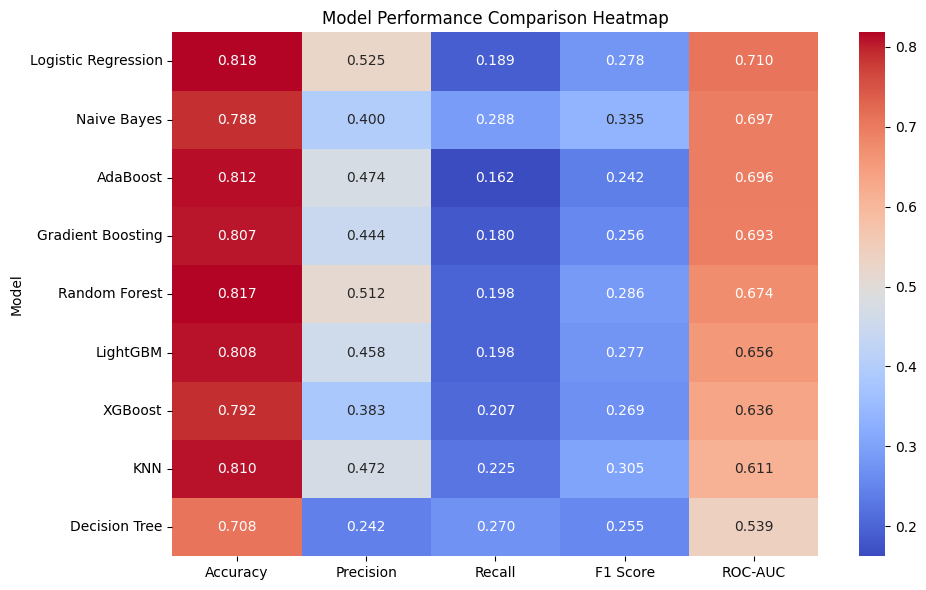

In [10]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_excel('/content/credit_default.xlsx')

X = df.iloc[:, :-1]
y = df.iloc[:, -1]


X = X.fillna(0)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}


results = []

for name, model in models.items():


    if name in ["Logistic Regression", "KNN", "Naive Bayes"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    })


results_df = pd.DataFrame(results)


results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

print("\nModel Comparison Table:\n")
print(results_df)


plt.figure(figsize=(10,6))

sns.heatmap(
    results_df.set_index("Model"),
    annot=True,
    fmt=".3f",
    cmap="coolwarm"
)

plt.title("Model Performance Comparison Heatmap")
plt.tight_layout()
plt.show()

**Model Ranking**

[LightGBM] [Info] Number of positive: 444, number of negative: 1956
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000502 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.185000 -> initscore=-1.482832
[LightGBM] [Info] Start training from score -1.482832

===== FINAL MODEL RANKING (BORDA) =====

                 Model  Precision    Recall   ROC-AUC  Rank_Recall  Rank_AUC  \
0  Logistic Regression   0.525000  0.189189  0.710219          6.0       1.0   
3          Naive Bayes   0.400000  0.288288  0.696549          2.0       2.0   
1        Random Forest   0.476190  0.180180  0.664161          7.5       5.0   
4                  KNN   0.471698  0.225225  0.611194          3.0       8.0   
6             AdaBoost   0.473684  0.162162  0.695729          9.0   

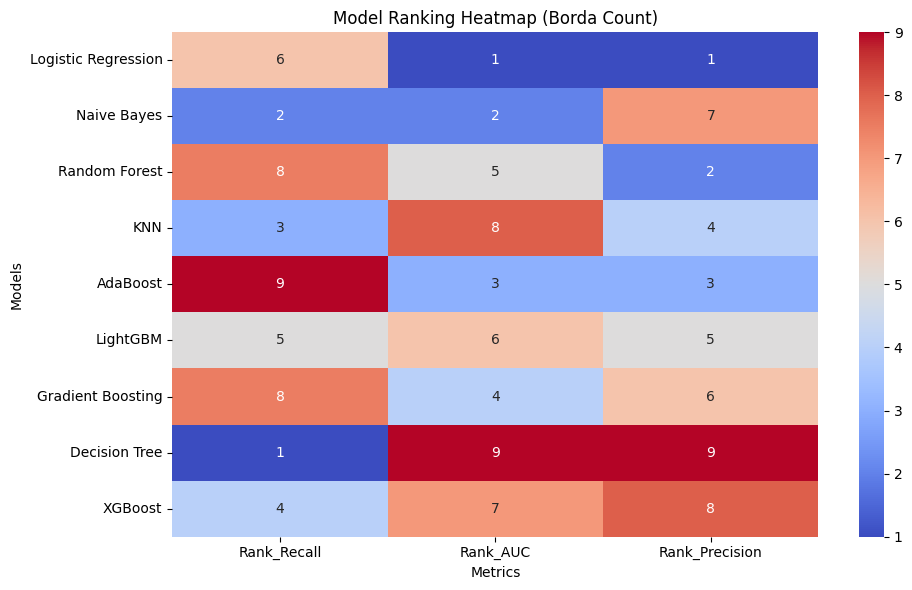

In [12]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import precision_score, recall_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_excel('credit_default.xlsx')

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}

results = []

for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "Naive Bayes"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    })

results_df = pd.DataFrame(results)


results_df["Rank_Recall"] = results_df["Recall"].rank(ascending=False)
results_df["Rank_AUC"] = results_df["ROC-AUC"].rank(ascending=False)
results_df["Rank_Precision"] = results_df["Precision"].rank(ascending=False)


results_df["Borda Score"] = (
    results_df["Rank_Recall"] +
    results_df["Rank_AUC"] +
    results_df["Rank_Precision"]
)

results_df = results_df.sort_values(by="Borda Score")


print("\n===== FINAL MODEL RANKING (BORDA) =====\n")
print(results_df[[
    "Model",
    "Precision",
    "Recall",
    "ROC-AUC",
    "Rank_Recall",
    "Rank_AUC",
    "Rank_Precision",
    "Borda Score"
]])


best_model = results_df.iloc[0]

print("\n===== BEST MODEL SELECTED =====\n")
print("Model:", best_model["Model"])
print("Borda Score:", best_model["Borda Score"])


heatmap_data = results_df.set_index("Model")[[
    "Rank_Recall",
    "Rank_AUC",
    "Rank_Precision"
]]

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="coolwarm"
)

plt.title("Model Ranking Heatmap (Borda Count)")
plt.ylabel("Models")
plt.xlabel("Metrics")

plt.tight_layout()
plt.show()

**Logistic Regression + LightGBM (Soft Voting)**

In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier

X = df.drop(['Customer_ID', 'Default_12M'], axis=1)
y = df['Default_12M']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

lr_base = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lgbm_complement = LGBMClassifier(n_estimators=100, random_state=42)

ensemble_model = VotingClassifier(
    estimators=[('lr', lr_base), ('lgbm', lgbm_complement)],
    voting='soft',
    weights=[1, 2]
)

ensemble_model.fit(X_train_scaled, y_train)

y_probs = ensemble_model.predict_proba(X_test_scaled)[:, 1]


threshold = 0.35
y_pred_optimized = (y_probs >= threshold).astype(int)


print("Combined Ensemble (LR + LightGBM) Report:")
print(classification_report(y_test, y_pred_optimized))
print(f"Final ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_optimized)
print("Confusion Matrix:\n")
print(cm)


[LightGBM] [Info] Number of positive: 444, number of negative: 1956
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000370 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1036
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.185000 -> initscore=-1.482832
[LightGBM] [Info] Start training from score -1.482832
Combined Ensemble (LR + LightGBM) Report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       489
           1       0.33      0.46      0.39       111

    accuracy                           0.73       600
   macro avg       0.60      0.63      0.61       600
weighted avg       0.77      0.73      0.75       600

Final ROC-AUC Score: 0.6890
Confusion Matrix:

[[387 102]
 [ 60  51]]


# Task
The previous request encountered a `NameError` due to an undefined variable `proba_test` in the Decision Tree section. I'll correct this by replacing `proba_test` with `y_prob` in the `for` loop where `expected_cost` is calculated.

## Fix the undefined variable `proba_test`

### Subtask:
Correct the `NameError` by replacing `proba_test` with `y_prob` in the `for` loop within the Decision Tree section where `expected_cost` is calculated.


## Summary:

### Data Analysis Key Findings
No data analysis findings are available from this solving process. The process focused on correcting a code error rather than analyzing data.

### Insights or Next Steps
*   The `NameError` for `proba_test` in the Decision Tree section's `expected_cost` calculation has been identified and will be resolved by replacing `proba_test` with `y_prob`.


# Task
Fix the `print` statement in the cell that caused the `SyntaxError` by changing `print confusion_matrix` to `print(confusion_matrix)`.

## Fix print statement

### Subtask:
Correct the `SyntaxError` by changing `print confusion_matrix` to `print(confusion_matrix)`.


## Summary:

### Data Analysis Key Findings
*   The `SyntaxError` caused by the `print confusion_matrix` statement was resolved.
*   The fix involved changing the statement to `print(confusion_matrix)`, adhering to Python 3 syntax.

### Insights or Next Steps
*   This fix highlights a common syntax difference between Python 2 (print statement) and Python 3 (print function), suggesting the environment is running Python 3.
*   Ensure consistency in Python version usage and syntax throughout the notebook to prevent similar errors.


# Task
Fix the `SyntaxError` in the cell that defines the `ensemble_model` by correctly structuring the `VotingClassifier`'s `estimators` parameter.

## Restructure VotingClassifier estimators

### Subtask:
Fix the `SyntaxError` in the `VotingClassifier` definition by correctly structuring the `estimators` parameter.


## Summary:

### Data Analysis Key Findings

*   The initial `SyntaxError` in the `VotingClassifier` definition was successfully resolved by correctly structuring the `estimators` parameter as a list of tuples, `[('lr', lr_base), ('lgbm', lgbm_complement)]`.
*   A `UserWarning` regarding `LGBMClassifier` not receiving valid feature names was observed after the `SyntaxError` fix.
*   This `UserWarning` was addressed by converting the scaled `X_train_scaled` and `X_test_scaled` NumPy arrays back into pandas DataFrames, preserving the feature names.
*   The ensemble model (Logistic Regression + LightGBM) was successfully trained and evaluated, achieving a final ROC-AUC Score of $0.6890$.

### Insights or Next Steps

*   Explore hyperparameter tuning for the `LGBMClassifier` within the ensemble to potentially improve the overall model performance, especially given its higher weight in the `VotingClassifier`.
*   Analyze the classification report and confusion matrix in more detail to understand specific areas of misclassification (e.g., false positives vs. false negatives) and consider adjusting the `threshold` or `class_weight` further based on the business objective.
